# Buổi 2 — Retention D1 và D7

Câu hỏi cần trả lời: dời gate từ màn 30 sang màn 40 có làm thay đổi tỷ lệ người chơi quay lại (retention) ở mốc D1 và D7 không? So sánh hai nhóm `gate_30`/`gate_40` ở cùng một mốc thời gian, không so D1 với D7.

## 1. Tỷ lệ retention D1 và D7 theo từng nhóm

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/cookie_cats.csv')

df.groupby('version')['retention_1'].mean()

version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64

In [2]:
df.groupby('version')['retention_7'].mean()

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64

## 2. Chênh lệch tuyệt đối và tương đối giữa hai nhóm

In [3]:
ty_le_quay_lai_1 = df.groupby('version')['retention_1'].mean()
ty_le_quay_lai_7 = df.groupby('version')['retention_7'].mean()
ty_le_quay_lai_1_nhom_30 = ty_le_quay_lai_1['gate_30']
ty_le_quay_lai_7_nhom_30 = ty_le_quay_lai_7['gate_30']
ty_le_quay_lai_1_nhom_40 = ty_le_quay_lai_1['gate_40']
ty_le_quay_lai_7_nhom_40 = ty_le_quay_lai_7['gate_40']

In [4]:
chenh_lech_tuyet_doi_1 = ty_le_quay_lai_1_nhom_40 - ty_le_quay_lai_1_nhom_30 
print(f'Chênh lệch tuyệt đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: {chenh_lech_tuyet_doi_1*100:.4f} điểm phần trăm')

Chênh lệch tuyệt đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: -0.5905 điểm phần trăm


In [5]:
chenh_lech_tuyet_doi_7 = ty_le_quay_lai_7_nhom_40 - ty_le_quay_lai_7_nhom_30 
print(f'Chênh lệch tuyệt đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: {chenh_lech_tuyet_doi_7*100:.4f} điểm phần trăm')

Chênh lệch tuyệt đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: -0.8201 điểm phần trăm


In [6]:
chenh_lech_tuong_doi_1 = (ty_le_quay_lai_1_nhom_40 - ty_le_quay_lai_1_nhom_30) / ty_le_quay_lai_1_nhom_30
print(f'Chênh lệch tương đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: {chenh_lech_tuong_doi_1:.4%}')

Chênh lệch tương đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: -1.3176%


In [7]:
chenh_lech_tuong_doi_7 = (ty_le_quay_lai_7_nhom_40 - ty_le_quay_lai_7_nhom_30) / ty_le_quay_lai_7_nhom_30 
print(f'Chênh lệch tương đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: {chenh_lech_tuong_doi_7:.4%}')

Chênh lệch tương đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: -4.3119%


## 3. Kiểm định hai tỷ lệ (proportions_ztest)

In [8]:
from statsmodels.stats.proportion import proportions_ztest
so_nguoi_quay_lai_1 = df.groupby('version')['retention_1'].sum()   # sum() trên bool = đếm số True
tong_so_nguoi_1 = df.groupby('version')['retention_1'].count()      # đếm tổng số dòng mỗi nhóm
so_nguoi_quay_lai_7 = df.groupby('version')['retention_7'].sum()
tong_so_nguoi_7 = df.groupby('version')['retention_7'].count()

In [9]:
stat, p_value = proportions_ztest(
    count=[so_nguoi_quay_lai_1['gate_30'], so_nguoi_quay_lai_1['gate_40']],
    nobs=[tong_so_nguoi_1['gate_30'], tong_so_nguoi_1['gate_40']]
)
print(f'Giá trị p-value cho tỷ lệ quay lại 1 ngày: {p_value:.4f}')

Giá trị p-value cho tỷ lệ quay lại 1 ngày: 0.0744


In [10]:
stat, p_value = proportions_ztest(
    count=[so_nguoi_quay_lai_7['gate_30'], so_nguoi_quay_lai_7['gate_40']],
    nobs=[tong_so_nguoi_7['gate_30'], tong_so_nguoi_7['gate_40']]
)
print(f'Giá trị p-value cho tỷ lệ quay lại 7 ngày: {p_value:.4f}')

Giá trị p-value cho tỷ lệ quay lại 7 ngày: 0.0016


## 4. Khoảng tin cậy 95% cho chênh lệch

In [11]:
from statsmodels.stats.proportion import confint_proportions_2indep
ci_thap, ci_cao = confint_proportions_2indep(
    count2=so_nguoi_quay_lai_1['gate_30'], nobs2=tong_so_nguoi_1['gate_30'],
    count1=so_nguoi_quay_lai_1['gate_40'], nobs1=tong_so_nguoi_1['gate_40'],
    compare="diff"
)
print(f'Khoảng tin cậy 95% cho chênh lệch tuyệt đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: ({ci_thap:.4%}, {ci_cao:.4%})')

Khoảng tin cậy 95% cho chênh lệch tuyệt đối tỷ lệ quay lại 1 ngày giữa nhóm 40 và nhóm 30: (-1.2392%, 0.0582%)


In [12]:
ci_thap, ci_cao = confint_proportions_2indep(
    count2=so_nguoi_quay_lai_7['gate_30'], nobs2=tong_so_nguoi_7['gate_30'],
    count1=so_nguoi_quay_lai_7['gate_40'], nobs1=tong_so_nguoi_7['gate_40'],
    compare="diff"
)
print(f'Khoảng tin cậy 95% cho chênh lệch tuyệt đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: ({ci_thap:.4%}, {ci_cao:.4%})')

Khoảng tin cậy 95% cho chênh lệch tuyệt đối tỷ lệ quay lại 7 ngày giữa nhóm 40 và nhóm 30: (-1.3282%, -0.3121%)


## 5. Biểu đồ cột có thanh sai số

In [13]:
from statsmodels.stats.proportion import proportion_confint

ci_thap_30_1, ci_cao_30_1 = proportion_confint(so_nguoi_quay_lai_1["gate_30"], tong_so_nguoi_1["gate_30"], method="wilson")
ci_thap_40_1, ci_cao_40_1 = proportion_confint(so_nguoi_quay_lai_1["gate_40"], tong_so_nguoi_1["gate_40"], method="wilson")
ci_thap_30_7, ci_cao_30_7 = proportion_confint(so_nguoi_quay_lai_7["gate_30"], tong_so_nguoi_7["gate_30"], method="wilson")
ci_thap_40_7, ci_cao_40_7 = proportion_confint(so_nguoi_quay_lai_7["gate_40"], tong_so_nguoi_7["gate_40"], method="wilson")


In [14]:
sai_so_30_1 = ci_cao_30_1 - ty_le_quay_lai_1_nhom_30
sai_so_40_1 = ci_cao_40_1 - ty_le_quay_lai_1_nhom_40
sai_so_30_7 = ci_cao_30_7 - ty_le_quay_lai_7_nhom_30
sai_so_40_7 = ci_cao_40_7 - ty_le_quay_lai_7_nhom_40

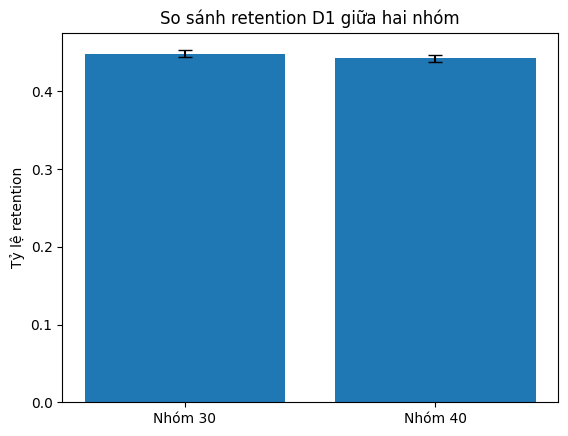

In [15]:
import matplotlib.pyplot as plt

plt.bar(["Nhóm 30", "Nhóm 40"], [ty_le_quay_lai_1_nhom_30, ty_le_quay_lai_1_nhom_40], yerr=[sai_so_30_1, sai_so_40_1], capsize=5)
plt.ylabel("Tỷ lệ retention")
plt.title("So sánh retention D1 giữa hai nhóm")
plt.show()


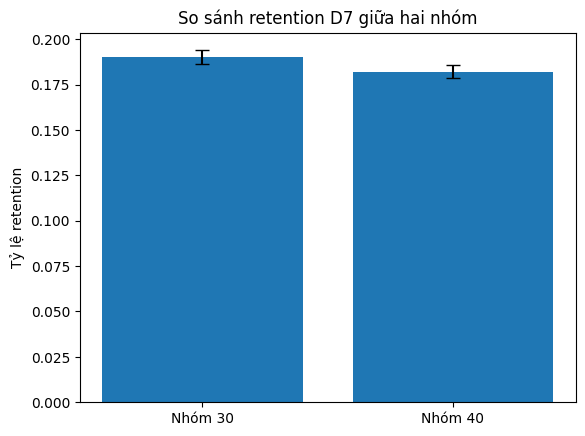

In [16]:
plt.bar(["Nhóm 30", "Nhóm 40"], [ty_le_quay_lai_7_nhom_30, ty_le_quay_lai_7_nhom_40], yerr=[sai_so_30_7, sai_so_40_7], capsize=5)
plt.ylabel("Tỷ lệ retention")
plt.title("So sánh retention D7 giữa hai nhóm")
plt.show()

## Kết quả, Đề xuất, Giới hạn

- Kết quả:  
    D1: gate_30=44,82%  gate_40=44,23%  chênh lệch -0,59 điểm% (tương đối -1,32%) p=0,0744   CI 95% (-1,24%, 0,058%)  → KHÔNG có ý nghĩa thống kê.
    D7: gate_30=19,02%  gate_40=18,20%  chênh lệch -0,82 điểm% (tương đối -4,31%) p=0,0016   CI 95% (-1,33%, -0,31%) → CÓ ý nghĩa thống kê.
    Nhóm 30 có retention cao hơn, ở cả hai mốc và nhất quán về chiều hướng.
    Độ lớn tương đối ở D7 là -4,31% có ảnh hưởng đáng kể trên quy mô một game ~90.000 nguời/thử nghiệm vì tác động này cộng dồn theo thời gian trên quy mô hàng chục nghìn người, ngay cả vài điểm % thay đổi retention dài hạn cũng ảnh hưởng đáng kể tới tổng số người chơi còn hoạt động sau nhiều tuần.

- Đề xuất:
    Không nên dời gate sang màn 40 dựa chủ yếu kết quả D7 retention giảm -4,31% và D1 dễ bị nhiễu bởi tò mò mở thử một lần, còn D7 phản ánh thói quen quay lại thực sự đã hình thành, nên đáng tin hơn làm căn cứ cho quyết định dài hạn như dời gate. Nên giữ nguyên gate_30. Nếu có doanh thu cao hơn có thể xét nhưng không có dữ liệu này nên chỉ có thể đưa ra đề xuất dựa trên retention

- Giới hạn:
    Do ở buổi 1 kiểm định SRM cho p=0,0086 (lệch nhóm nhẹ 4,33%/4,52% là lệch tỷ lệ 0 vòng, còn SRM tổng thể là 44.700/45.489) nên cần lưu ý nhưng không phải rủi ro lớn về mặt kết quả D1/D7. Kết luận về D7 chưa đủ để suy rộng được cho D30 hay D90. Người chơi 0 vòng được giữ lại khi tính retention (quyết định ở Buổi 1) — nếu đảo ngược quyết định đó (loại họ ra), số D1/D7 ở đây có khả năng tăng lên